# Compare the longitudinal intra donor variability of ARI and con2
- compare the variability of healthy control CON2 and ARI longitudinally
- calculate the CV for ALTRA converters and BRI healthy
- compared the CV

In [1]:
# load library
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("data.table")
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("Matrix")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("future")
quiet_library("future.apply")
quiet_library("PALMO")
quiet_library("scran")
quiet_library("SingleCellExperiment")
quiet_library("DESeq2")
quiet_library("ggpubr")
quiet_library("parallel")

In [2]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
ari_colors <- c("#4C8CBD", "#F59F00", "#840032")
options(repr.plot.width = 20, repr.plot.height = 15)

In [3]:
# define file path
# define working path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/output_results_oldIDE/output_results/integration"
fig_path <- "/home/workspace/data/ra_longitudinal/figures/integration"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
output_path <- "/home/workspace/data/ra_longitudinal/output_results/certPro"

if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "ALTRA_AIM3_BRI_scRNA_PALMO_"

In [4]:
#' DEseq2Norm
#'
#' This function performs DESeq2 normalization on a given SummarizedExperiment object.
#'
#' @param pb_se A SummarizedExperiment object containing the raw counts to be normalized.
#'
#' @return A SummarizedExperiment object with an added assay containing the variance stabilized transformed counts.
#'
#' @details
#' The function first creates a DESeqDataSet object with a design formula of `~ 1`, indicating no specific design.
#' It then applies the variance stabilizing transformation (VST) to the DESeqDataSet object.
#' The resulting VST counts are added as a new assay to the input SummarizedExperiment object.
#'
#' @import DESeq2
#' @import SummarizedExperiment
#'
#' @examples
#' \dontrun{
#' library(DESeq2)
#' library(SummarizedExperiment)
#' 
#' # Example usage
#' pb_se <- SummarizedExperiment(assays = list(counts = matrix(rpois(100, lambda = 10), ncol = 10)))
#' pb_se <- DEseq2Norm(pb_se)
#' }

DEseq2Norm <- function(pb_se) {
    # get deseq2 normalized counts
    # run deseq to get normalized counts
    pb_des <- DESeqDataSet(pb_se, design = as.formula("~ 1"))
    vsd <- varianceStabilizingTransformation(pb_des, blind = TRUE)
    assay(pb_se, "vst") <- assay(vsd)
    return(pb_se)
}

#' Compare_CV
#'
#' This function performs a cross-validation (CV) comparison for a specified cell type using provided pseudobulk data.
#'
#' @param celltype_test A character string specifying the cell type to test.
#' @param pb_data A SummarizedExperiment object containing pseudobulk data.
#' @param n_cores An integer specifying the number of cores to use for parallel processing. Default is 1.
#'
#' @return A tibble containing combined CV distributions for the specified cell type, with status annotations.
#'
#' @details
#' The function filters the input data based on the specified cell type and performs several preprocessing steps,
#' including filtering low-expressed genes and normalizing the data using DESeq2. It then creates PALMO data objects
#' for both converters and healthy samples, annotates metadata, merges data, and calculates CV distributions.
#' Finally, it combines the CV distributions for converters and healthy samples and returns the result as a tibble.
#'
#' @examples
#' \dontrun{
#' # Example usage:
#' result <- Compare_CV(celltype_test = "T_cells", pb_data = pseudobulk_data, n_cores = 4)
#' }
#'
#' @import SummarizedExperiment
#' @import SingleCellExperiment
#' @import DESeq2
#' @import dplyr
#' @import PALMO
#' @import tibble
#' @importFrom magrittr %>%
#' @importFrom stats na.omit
#' @importFrom scales scale
#' @export

Compare_CV <- function(celltype_test, pb_data, n_cores = 1) {
    message(paste("processing", celltype_test))
    # filter on cell type
    pb_se <- pb_data[, colData(pb_se_lg)$cell_type == celltype_test]
    # # do some general filter to low expressed genes
    smallestGroupSize <- 30
    keep <- rowSums(assay(pb_se, "counts") >= 10) >= smallestGroupSize
    pb_se <- pb_se[keep, ]
    # run deseq2 and batch normalizatoin
    pb_se <- DEseq2Norm(pb_se)
    message(paste("processing", as.character(nrow(pb_se)), "genes"))
    pb_sce <- as(pb_se, "SingleCellExperiment")
    # subset the longitudinal ALTRA model
    pb_ra <- pb_sce[, (!is.na(colData(pb_sce)$days_to_conversion)) &
        (colData(pb_sce)$days_to_conversion > -750)]

    # create a palmo data object
    colnames(pb_ra) <- colData(pb_ra)$sample.sampleKitGuid
    expression <- assay(pb_ra, "vst")
    metadata <- colData(pb_ra) %>%
        as.data.frame() %>%
        mutate(
            Sample = sample.sampleKitGuid,
            days_to_conversion_scale = scale(days_to_conversion)
        )
    palmo_ra <- createPALMOobject(anndata = metadata, data = expression)

    palmo_ra <- annotateMetadata(
        data_object = palmo_ra,
        sample_column = "Sample",
        donor_column = "subject.subjectGuid",
        time_column = "days_to_conversion"
    )
    # Sample overlap and final matrix
    palmo_ra <- mergePALMOdata(data_object = palmo_ra, datatype = "bulk")
    # CV distribution
    cv_ra <- cvCalcBulkProfile(data_object = palmo_ra, cl = n_cores)

    # subset the longitudinal ALTRA model
    pb_bri <- pb_sce[, colData(pb_sce)$status == "BRI_healthy"]

    # create a palmo data object
    colnames(pb_bri) <- colData(pb_bri)$sample.sampleKitGuid
    expression <- assay(pb_bri, "vst")
    metadata <- colData(pb_bri) %>%
        as.data.frame() %>%
        mutate(Sample = sample.sampleKitGuid)
    palmo_bri <- createPALMOobject(anndata = metadata, data = expression)

    palmo_bri <- annotateMetadata(
        data_object = palmo_bri,
        sample_column = "Sample",
        donor_column = "subject.subjectGuid",
        time_column = "days_since_last"
    )
    # Sample overlap and final matrix
    palmo_bri <- mergePALMOdata(data_object = palmo_bri, datatype = "bulk")
    # CV distribution
    cv_bri <- suppressMessages(cvCalcBulkProfile(data_object = palmo_bri, cl = n_cores))
    # combine CV
    cv_comb <- as_tibble(cv_ra) %>%
        mutate(status = "converters") %>%
        bind_rows(as_tibble(cv_bri) %>% mutate(status = "bri_healthy")) %>%
        mutate(cell_type = celltype_test)
    return(cv_comb)
}

# load pseudobulk data for all AIMs
- inclduding BRI longitudinal

In [6]:
# load pseudobulk data for all samples
pb_se_all <- readRDS("/home/workspace/data/ALTRA_manusript/ALTRA_BRI_longitudinal_l2_psedobulk_object_090324.rds")

In [7]:
# add status column
pb_se_all$status <- replace_na(pb_se_all$status, "BRI_healthy")

In [8]:
# check sample number
colData(pb_se_all) %>%
  as_tibble() %>%
  distinct(sample.sampleKitGuid,
    .keep_all = TRUE
  ) %>%
  group_by(status) %>%
  tally()

status,n
<chr>,<int>
BRI_healthy,86
at_risk,54
conversion,10
early_RA,1


In [9]:
# filter days to conversion to less than -750 days
pb_se_lg <- pb_se_all[, is.na(pb_se_all$days_to_conversion) | pb_se_all$days_to_conversion > (-750)]

In [10]:
pb_se_lg

class: SummarizedExperiment 
dim: 28824 3457 
metadata(0):
assays(1): counts
rownames(28824): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(0):
colnames(3457): KT00052 KT00056 ... KT03918 KT03921
colData names(51): index batch_id ... cell_type bmi_conv_cat

In [11]:
colData(pb_se_lg) %>%
  as_tibble() %>%
  distinct(sample.sampleKitGuid,
    .keep_all = TRUE
  ) %>%
  group_by(status) %>%
  tally()

status,n
<chr>,<int>
BRI_healthy,86
at_risk,48
conversion,10
early_RA,1


# use PLAMO to identify the time variable genes in altra longitudinal

In [12]:
pb_sce <- as(pb_se_lg, "SingleCellExperiment")

[1] "index"                               "batch_id"                           
 [3] "hto_barcode"                         "hto_category"                       
 [5] "pbmc_sample_id"                      "pool_id"                            
 [7] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
 [9] "subject.subjectGuid"                 "subject.biologicalSex"              
[11] "subject.race"                        "subject.ethnicity"                  
[13] "subject.birthYear"                   "sample.visitName"                   
[15] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[17] "sample.daysSinceFirstVisit"          "file.id"                            
[19] "subset_grp"                          "predicted_doublet"                  
[21] "AIFI_L2"                             "doublets_manual"                    
[23] "Status_Xsec"                         "Status_Long"                        
[25] "anti_ccp3_finalCombined"             "days_to_conversion"                 
[27] "BMI"                                 "CMV_Status_Subj"                    
[29] "age_conv"                            "bmi_conv"                           
[31] "file.batchID"                        "status"                             
[33] "psbulk_n_cells"                      "psbulk_counts"                      
[35] "cohort"                              "AIFI_L1"                            
[37] "subject.cmv"                         "subject.ageAtFirstDraw"             
[39] "sample.subjectAgeAtDraw"             "specimen.specimenGuid"              
[41] "pipeline.fileGuid"                   "age"                                
[43] "days_since_first"                    "lib_size"                           
[45] "log_lib_size"                        "age_last"                           
[47] "bmi_last"                            "last_visit_day"                     
[49] "days_since_last"                     "cell_type"                          
[51] "bmi_conv_cat"

[1] "at_risk"     "conversion"  "early_RA"    "BRI_healthy"

In [13]:
colnames(pb_sce) <- paste(colnames(pb_sce), pb_sce$cell_type, sep = "_")

# loop for all cell types

In [14]:
pb_sce

class: SingleCellExperiment 
dim: 28824 3457 
metadata(0):
assays(1): counts
rownames(28824): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(0):
colnames(3457): KT00052_CD14 monocyte KT00056_CD14 monocyte ...
  KT03918_pDC KT03921_pDC
colData names(51): index batch_id ... cell_type bmi_conv_cat
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [87]:
# calculate sample number in different cell type
celltype_counts <- colData(pb_se_lg) %>%
  as_tibble() %>%
  group_by(cell_type, cohort) %>%
  tally()
celltype_counts %>% head()

cell_type,cohort,n
<chr>,<chr>,<int>
ASDC,ALTRA,2
ASDC,BRI,6
CD14 monocyte,ALTRA,135
CD14 monocyte,BRI,89
CD16 monocyte,ALTRA,135
CD16 monocyte,BRI,89


In [91]:
rare_celltypes <- celltype_counts %>% filter(n < 15)
rare_celltypes
l2_celltypes <- pb_se_all$cell_type %>% unique()
l2_celltypes <- l2_celltypes[!l2_celltypes %in% rare_celltypes$cell_type]
l2_celltypes %>% length()

cell_type,cohort,n
<chr>,<chr>,<int>
ASDC,ALTRA,2
ASDC,BRI,6


[1] 28

In [ ]:
# run CV calculation with PALMO
celltype_cv <- mclapply(l2_celltypes, Compare_CV,
  pb_data = pb_se_lg,
  n_cores = 15, mc.cores = 1
) %>% rbindlist()

In [ ]:
celltype_cv %>% head()

In [ ]:
celltype_cv %>% write_tsv(file.path(output_path, 'ALTRA_AIM3_BRI_scRNA_PALMO_CV_celltype_090324.tsv'))

### upload results to HISE

In [1]:
# upload CV calculation results to collab space
hise::uploadFiles(
  files = list("/home/workspace/data/ALTRA_manusript/ALTRA_AIM3_BRI_scRNA_PALMO_CV_celltype_090324.tsv"),
  studySpaceId = "223de760-9624-45bd-aefe-ca24c75b1800",
  title = "ALTRA ALTRS CON2 scRNA longitudinal AIFI L2 psedobulk object",
  inputFileIds = as.list("97bc72bf-783e-4aaa-998b-149edda0cee0")
)

## analyze the cv results

In [48]:
# load cv data
celltype_cv <- fread(
  "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/output_results_oldIDE/output_results/certPro_results/ALTRA_AIM3_BRI_scRNA_PALMO_CV_celltype.tsv"
)
celltype_cv2 <- fread(
  "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/output_results_oldIDE/output_results/certPro_results/ALTRA_AIM3_BRI_scRNA_PALMO_CV_celltype_090324.tsv"
)

In [69]:
# calculate the ratio of CVs
celltype_cv_ratio <- celltype_cv %>%
  group_by(cell_type, feature, status) %>%
  summarise(mean_cv = mean(CV)) %>%
  arrange(feature) %>%
  pivot_wider(names_from = "status", values_from = "mean_cv") %>%
  filter(!is.na(converters) & !is.na(bri_healthy)) %>%
  mutate(ratio_cv = converters / bri_healthy) %>%
  mutate(direction = factor(if_else(ratio_cv > 1, "Higher CV in ARI to Clincal RA",
    "Higher CV in CON2"
  ), levels = c("Higher CV in CON2", "Higher CV in ARI to Clincal RA"))) %>%
  rename(
    "cell_type" = "Cell type", "feature" = "Gene", "bri_healthy" = "mean CV in CON2",
    "converters" = "mean CV in ARI (Converters)",
    "ratio_cv" = "Ratio of CV (Conveters / CON2)"
  )

`summarise()` has grouped output by 'cell_type', 'feature'. You can override
using the `.groups` argument.


In [70]:
# calculate the ratio of CVs
celltype_cv_ratio2 <- celltype_cv2 %>%
  group_by(cell_type, feature, status) %>%
  summarise(mean_cv = mean(CV)) %>%
  arrange(feature) %>%
  pivot_wider(names_from = "status", values_from = "mean_cv") %>%
  filter(!is.na(converters) & !is.na(bri_healthy)) %>%
  mutate(ratio_cv = converters / bri_healthy) %>%
  mutate(direction = factor(if_else(ratio_cv > 1, "Higher CV in ARI to Clincal RA",
    "Higher CV in CON2"
  ), levels = c("Higher CV in CON2", "Higher CV in ARI to Clincal RA"))) %>%
  rename(
    "cell_type" = "Cell type", "feature" = "Gene", "bri_healthy" = "mean CV in CON2",
    "converters" = "mean CV in ARI (Converters)",
    "ratio_cv" = "Ratio of CV (Conveters / CON2)"
  )

`summarise()` has grouped output by 'cell_type', 'feature'. You can override
using the `.groups` argument.


In [72]:
# calcualte the counts of genes
cv_direction_counts <- celltype_cv_ratio %>%
  filter(`Cell type` != "cDC1") %>%
  group_by(`Cell type`, direction) %>%
  tally() %>%
  mutate(counts = if_else(direction == "Higher CV in converters", -n, n), pct = prop.table(n))
cv_direction_counts %>% head()

Cell type,direction,n,counts,pct
<chr>,<fct>,<int>,<int>,<dbl>
CD14 monocyte,Higher CV in CON2,2359,2359,0.17417307
CD14 monocyte,Higher CV in ARI to Clincal RA,11185,11185,0.82582693
CD16 monocyte,Higher CV in CON2,1580,1580,0.14714099
CD16 monocyte,Higher CV in ARI to Clincal RA,9158,9158,0.85285901
CD56bright NK cell,Higher CV in CON2,652,652,0.09148309
CD56bright NK cell,Higher CV in ARI to Clincal RA,6475,6475,0.90851691


In [74]:
# calcualte the counts of genes
cv_direction_counts2 <- celltype_cv_ratio2 %>%
  filter(`Cell type` != "cDC1") %>%
  group_by(`Cell type`, direction) %>%
  tally() %>%
  mutate(counts = if_else(direction == "Higher CV in converters", -n, n), pct = prop.table(n))
cv_direction_counts2 %>% head()

Cell type,direction,n,counts,pct
<chr>,<fct>,<int>,<int>,<dbl>
CD14 monocyte,Higher CV in CON2,3276,3276,0.2483135
CD14 monocyte,Higher CV in ARI to Clincal RA,9917,9917,0.7516865
CD16 monocyte,Higher CV in CON2,2862,2862,0.2783505
CD16 monocyte,Higher CV in ARI to Clincal RA,7420,7420,0.7216495
CD56bright NK cell,Higher CV in CON2,1088,1088,0.1632653
CD56bright NK cell,Higher CV in ARI to Clincal RA,5576,5576,0.8367347


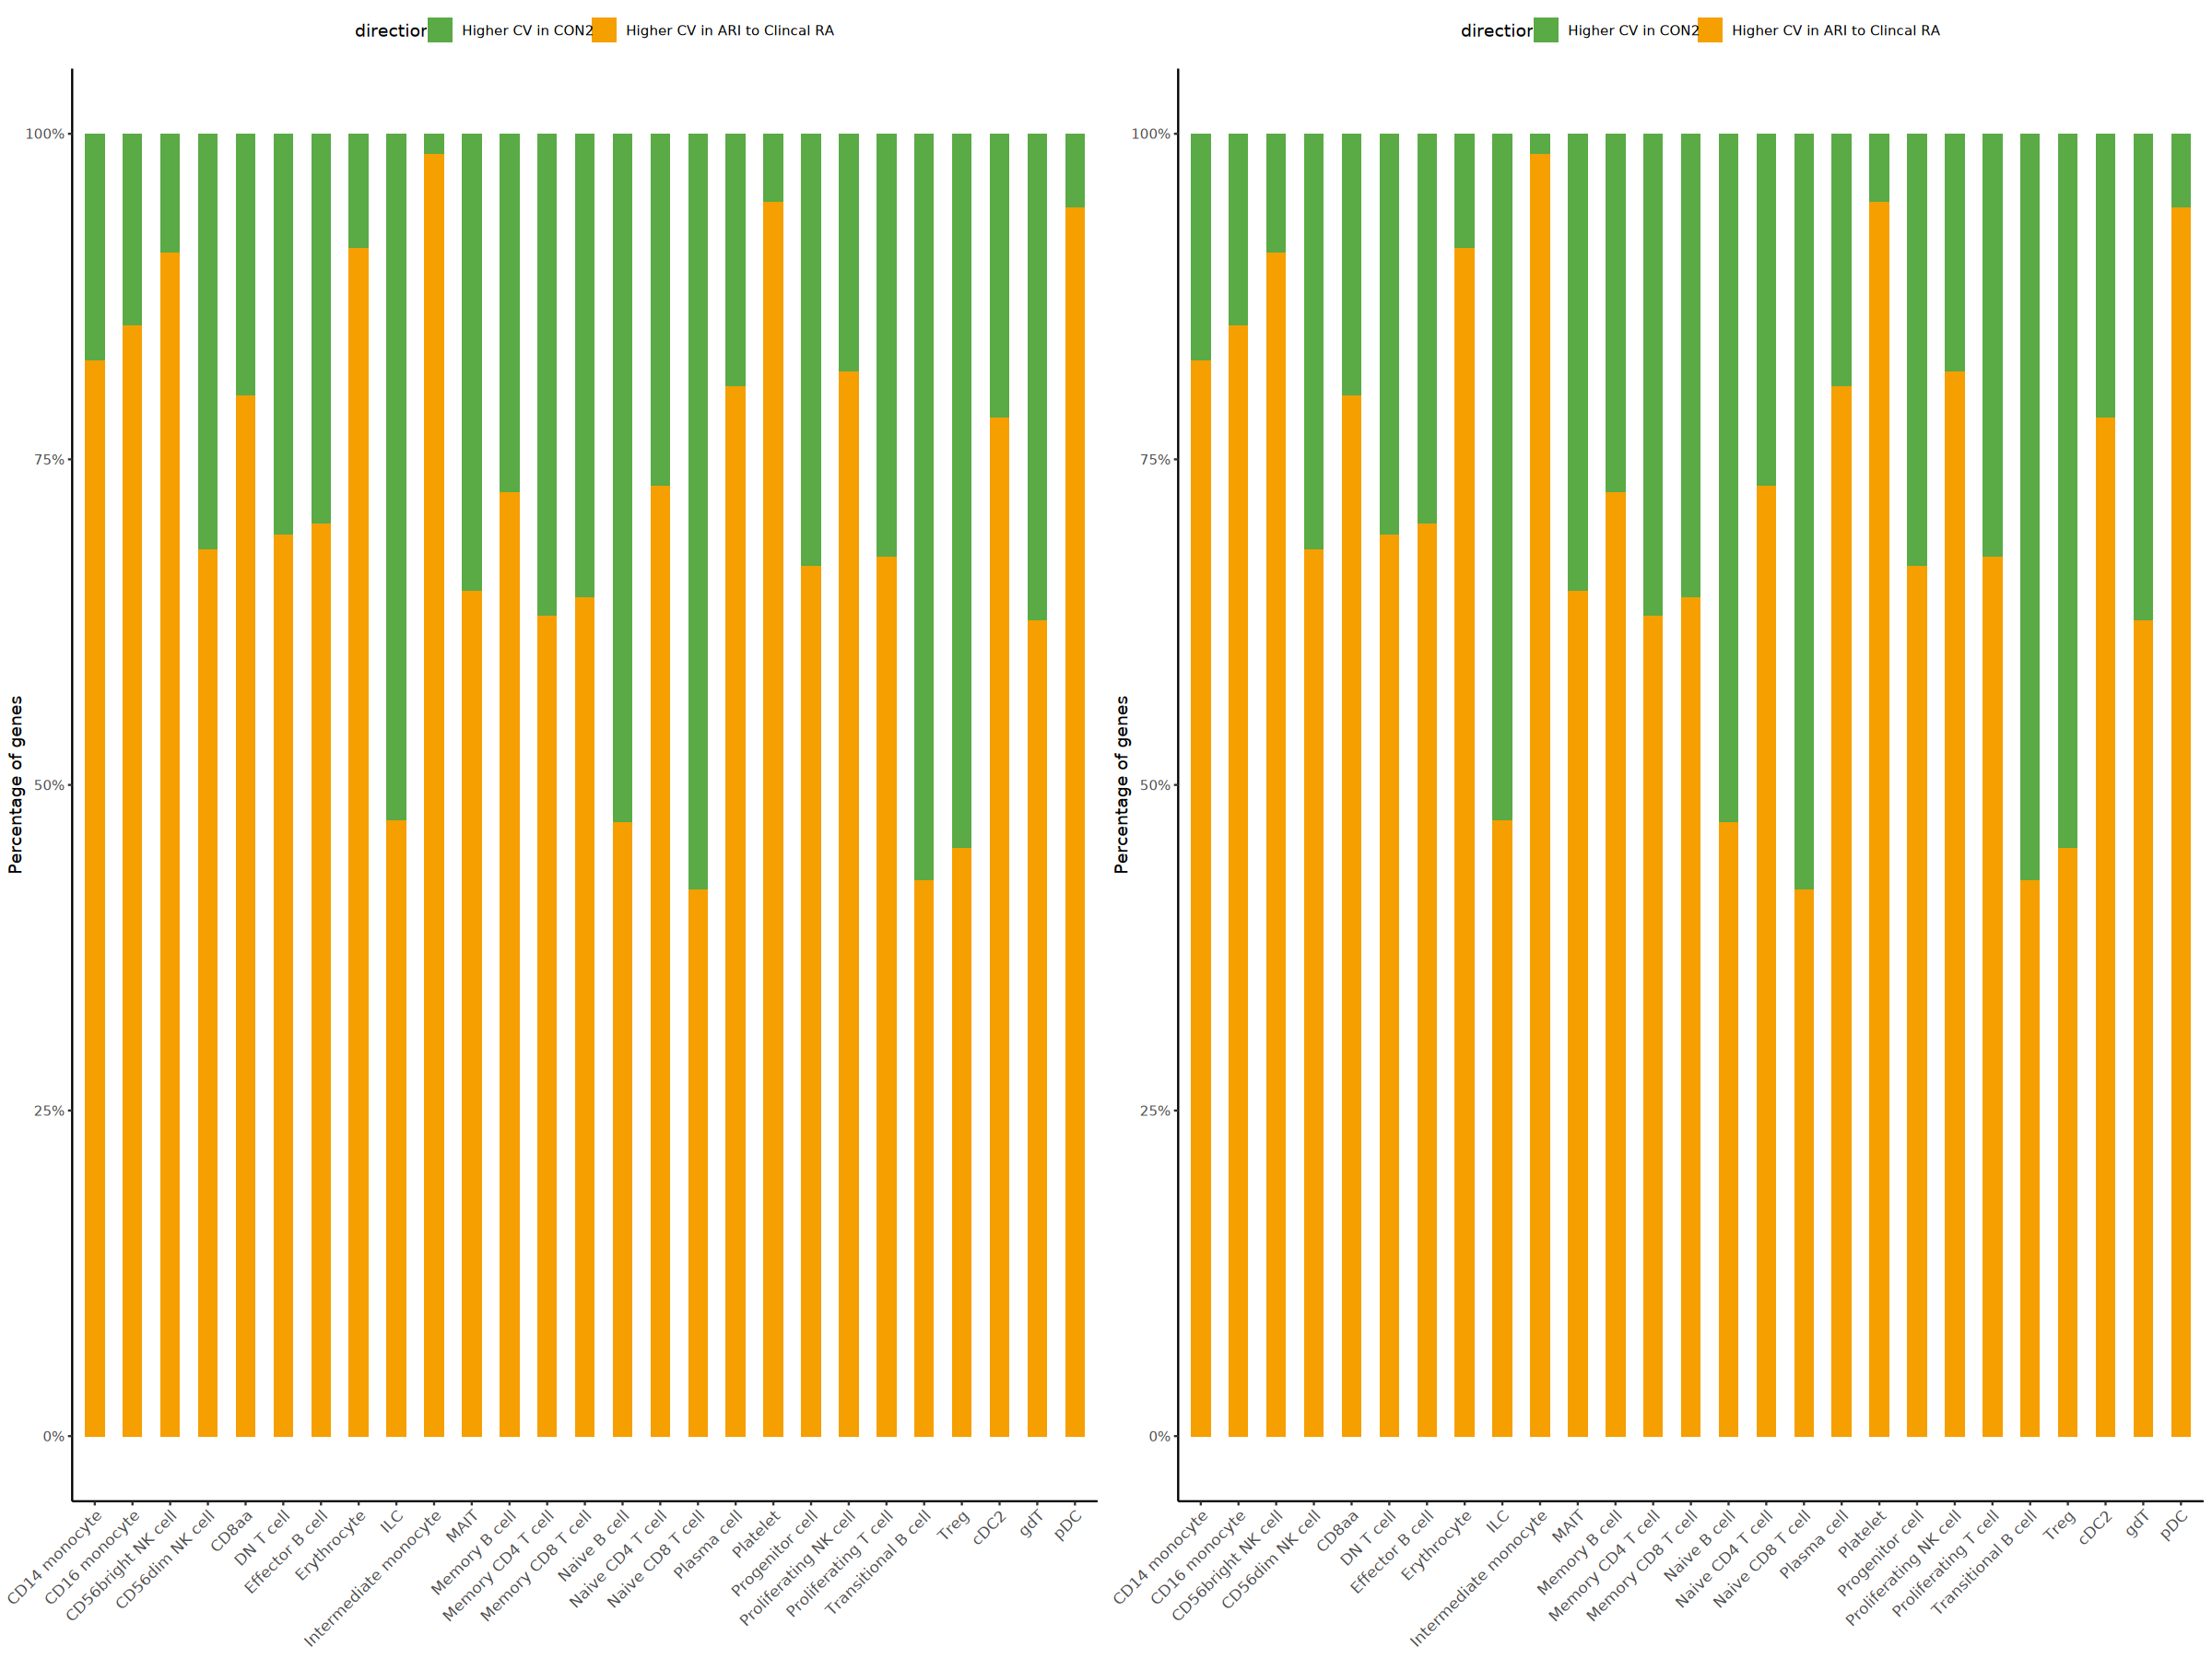

In [75]:
p1 <- ggplot(cv_direction_counts, 
             aes(width = 0.5, fill = direction, y = pct, x = `Cell type`)) +
  geom_col() +
  ylab("Percentage of genes") +
  xlab("") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
    legend.position = "top",
    strip.text = element_text(size = 10)
  ) +
  scale_fill_manual(values = c(
    "#5AAA46",
    "#F59F00"
  )) +
  scale_y_continuous(labels = scales::percent)
p2 <- ggplot(cv_direction_counts, 
             aes(width = 0.5, fill = direction, y = pct, x = `Cell type`)) +
  geom_col() +
  ylab("Percentage of genes") +
  xlab("") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
    legend.position = "top",
    strip.text = element_text(size = 10)
  ) +
  scale_fill_manual(values = c(
    "#5AAA46",
    "#F59F00"
  )) +
  scale_y_continuous(labels = scales::percent)
cowplot::plot_grid(p1, p2)

In [43]:
# remove BR2024
celltype_cv <- celltype_cv %>% filter(group != "BR2024")

In [44]:
# calculate the ratio of CVs
celltype_cv_ratio <- celltype_cv %>%
  group_by(cell_type, feature, status) %>%
  summarise(mean_cv = mean(CV)) %>%
  arrange(feature) %>%
  pivot_wider(names_from = "status", values_from = "mean_cv") %>%
  filter(!is.na(converters) & !is.na(bri_healthy)) %>%
  mutate(ratio_cv = converters / bri_healthy) %>%
  mutate(direction = factor(if_else(ratio_cv > 1, "Higher CV in ARI to Clincal RA",
    "Higher CV in CON2"
  ), levels = c("Higher CV in CON2", "Higher CV in ARI to Clincal RA")))

`summarise()` has grouped output by 'cell_type', 'feature'. You can override
using the `.groups` argument.


In [45]:
celltype_cv %>% head()

mean,sd,var,CV,NAs,zeros,feature,group,status,cell_type
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
10.331672,0.21465352,0.046076133,2.077626,0,0,A1BG,CU1003,converters,CD14 monocyte
6.925017,0.10214791,0.010434195,1.475056,0,0,A1BG-AS1,CU1003,converters,CD14 monocyte
6.028399,0.20973234,0.043987654,3.479072,0,0,A2M-AS1,CU1003,converters,CD14 monocyte
7.494086,0.09604312,0.009224282,1.281585,0,0,AAAS,CU1003,converters,CD14 monocyte
6.684095,0.16929209,0.028659810,2.532760,0,0,AACS,CU1003,converters,CD14 monocyte
8.881343,0.15561135,0.024214892,1.752115,0,0,AAED1,CU1003,converters,CD14 monocyte


In [46]:
# output the sup table
table_s14 <- celltype_cv_ratio %>%
  rename(
    "cell_type" = "Cell type", "feature" = "Gene", "bri_healthy" = "mean CV in CON2",
    "converters" = "mean CV in ARI (Converters)",
    "ratio_cv" = "Ratio of CV (Conveters / CON2)"
  )
table_s14 %>% head()


Cell type,Gene,mean CV in CON2,mean CV in ARI (Converters),Ratio of CV (Conveters / CON2),direction
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
CD14 monocyte,A1BG,1.426455,1.680691,1.1782292,Higher CV in ARI to Clincal RA
CD16 monocyte,A1BG,2.643327,3.135730,1.1862813,Higher CV in ARI to Clincal RA
CD56bright NK cell,A1BG,3.546346,3.003404,0.8469011,Higher CV in CON2
CD56dim NK cell,A1BG,2.365655,2.488283,1.0518368,Higher CV in ARI to Clincal RA
DN T cell,A1BG,5.534718,6.452657,1.1658510,Higher CV in ARI to Clincal RA
Effector B cell,A1BG,4.149200,4.288964,1.0336845,Higher CV in ARI to Clincal RA


In [ ]:
table_s14 %>% write_csv(file.path(output_path, "TableS14_ALTRA_CON2_CV_comparison.csv"))

In [79]:
table_s14 <- read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/TableS14_ALTRA_CON2_CV_comparison.csv',
                     show_col_types = FALSE)%>% 
    mutate(direction= factor(direction, levels = c('Higher CV in CON2', 'Higher CV in ARI to Clincal RA')))
table_s14 %>% head()

Cell type,Gene,mean CV in CON2,mean CV in ARI (Converters),Ratio of CV (Conveters / CON2),direction
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
CD14 monocyte,A1BG,1.429729,1.700912,1.1896738,Higher CV in ARI to Clincal RA
CD16 monocyte,A1BG,2.588810,3.105737,1.1996775,Higher CV in ARI to Clincal RA
CD56bright NK cell,A1BG,3.546172,3.007361,0.8480584,Higher CV in CON2
CD56dim NK cell,A1BG,2.318540,2.451917,1.0575262,Higher CV in ARI to Clincal RA
DN T cell,A1BG,4.970682,5.782211,1.1632630,Higher CV in ARI to Clincal RA
Effector B cell,A1BG,3.970334,4.104459,1.0337817,Higher CV in ARI to Clincal RA


In [81]:
# table_s14%>% arrange(`Cell type`)

In [82]:
# calcualte the counts of genes
cv_direction_counts <- table_s14 %>%
  filter(`Cell type` != "cDC1") %>% 
  group_by(`Cell type`, direction) %>%
  tally() %>%
  mutate(`Cell type` = factor(`Cell type`, levels = sort(unique(table_s14$`Cell type`))),
         counts = if_else(direction == "Higher CV in converters", -n, n), pct = prop.table(n))
cv_direction_counts %>% head()

Cell type,direction,n,counts,pct
<fct>,<fct>,<int>,<int>,<dbl>
CD14 monocyte,Higher CV in CON2,1142,1142,0.14912510
CD14 monocyte,Higher CV in ARI to Clincal RA,6516,6516,0.85087490
CD16 monocyte,Higher CV in CON2,723,723,0.12104470
CD16 monocyte,Higher CV in ARI to Clincal RA,5250,5250,0.87895530
CD56bright NK cell,Higher CV in CON2,264,264,0.07179766
CD56bright NK cell,Higher CV in ARI to Clincal RA,3413,3413,0.92820234


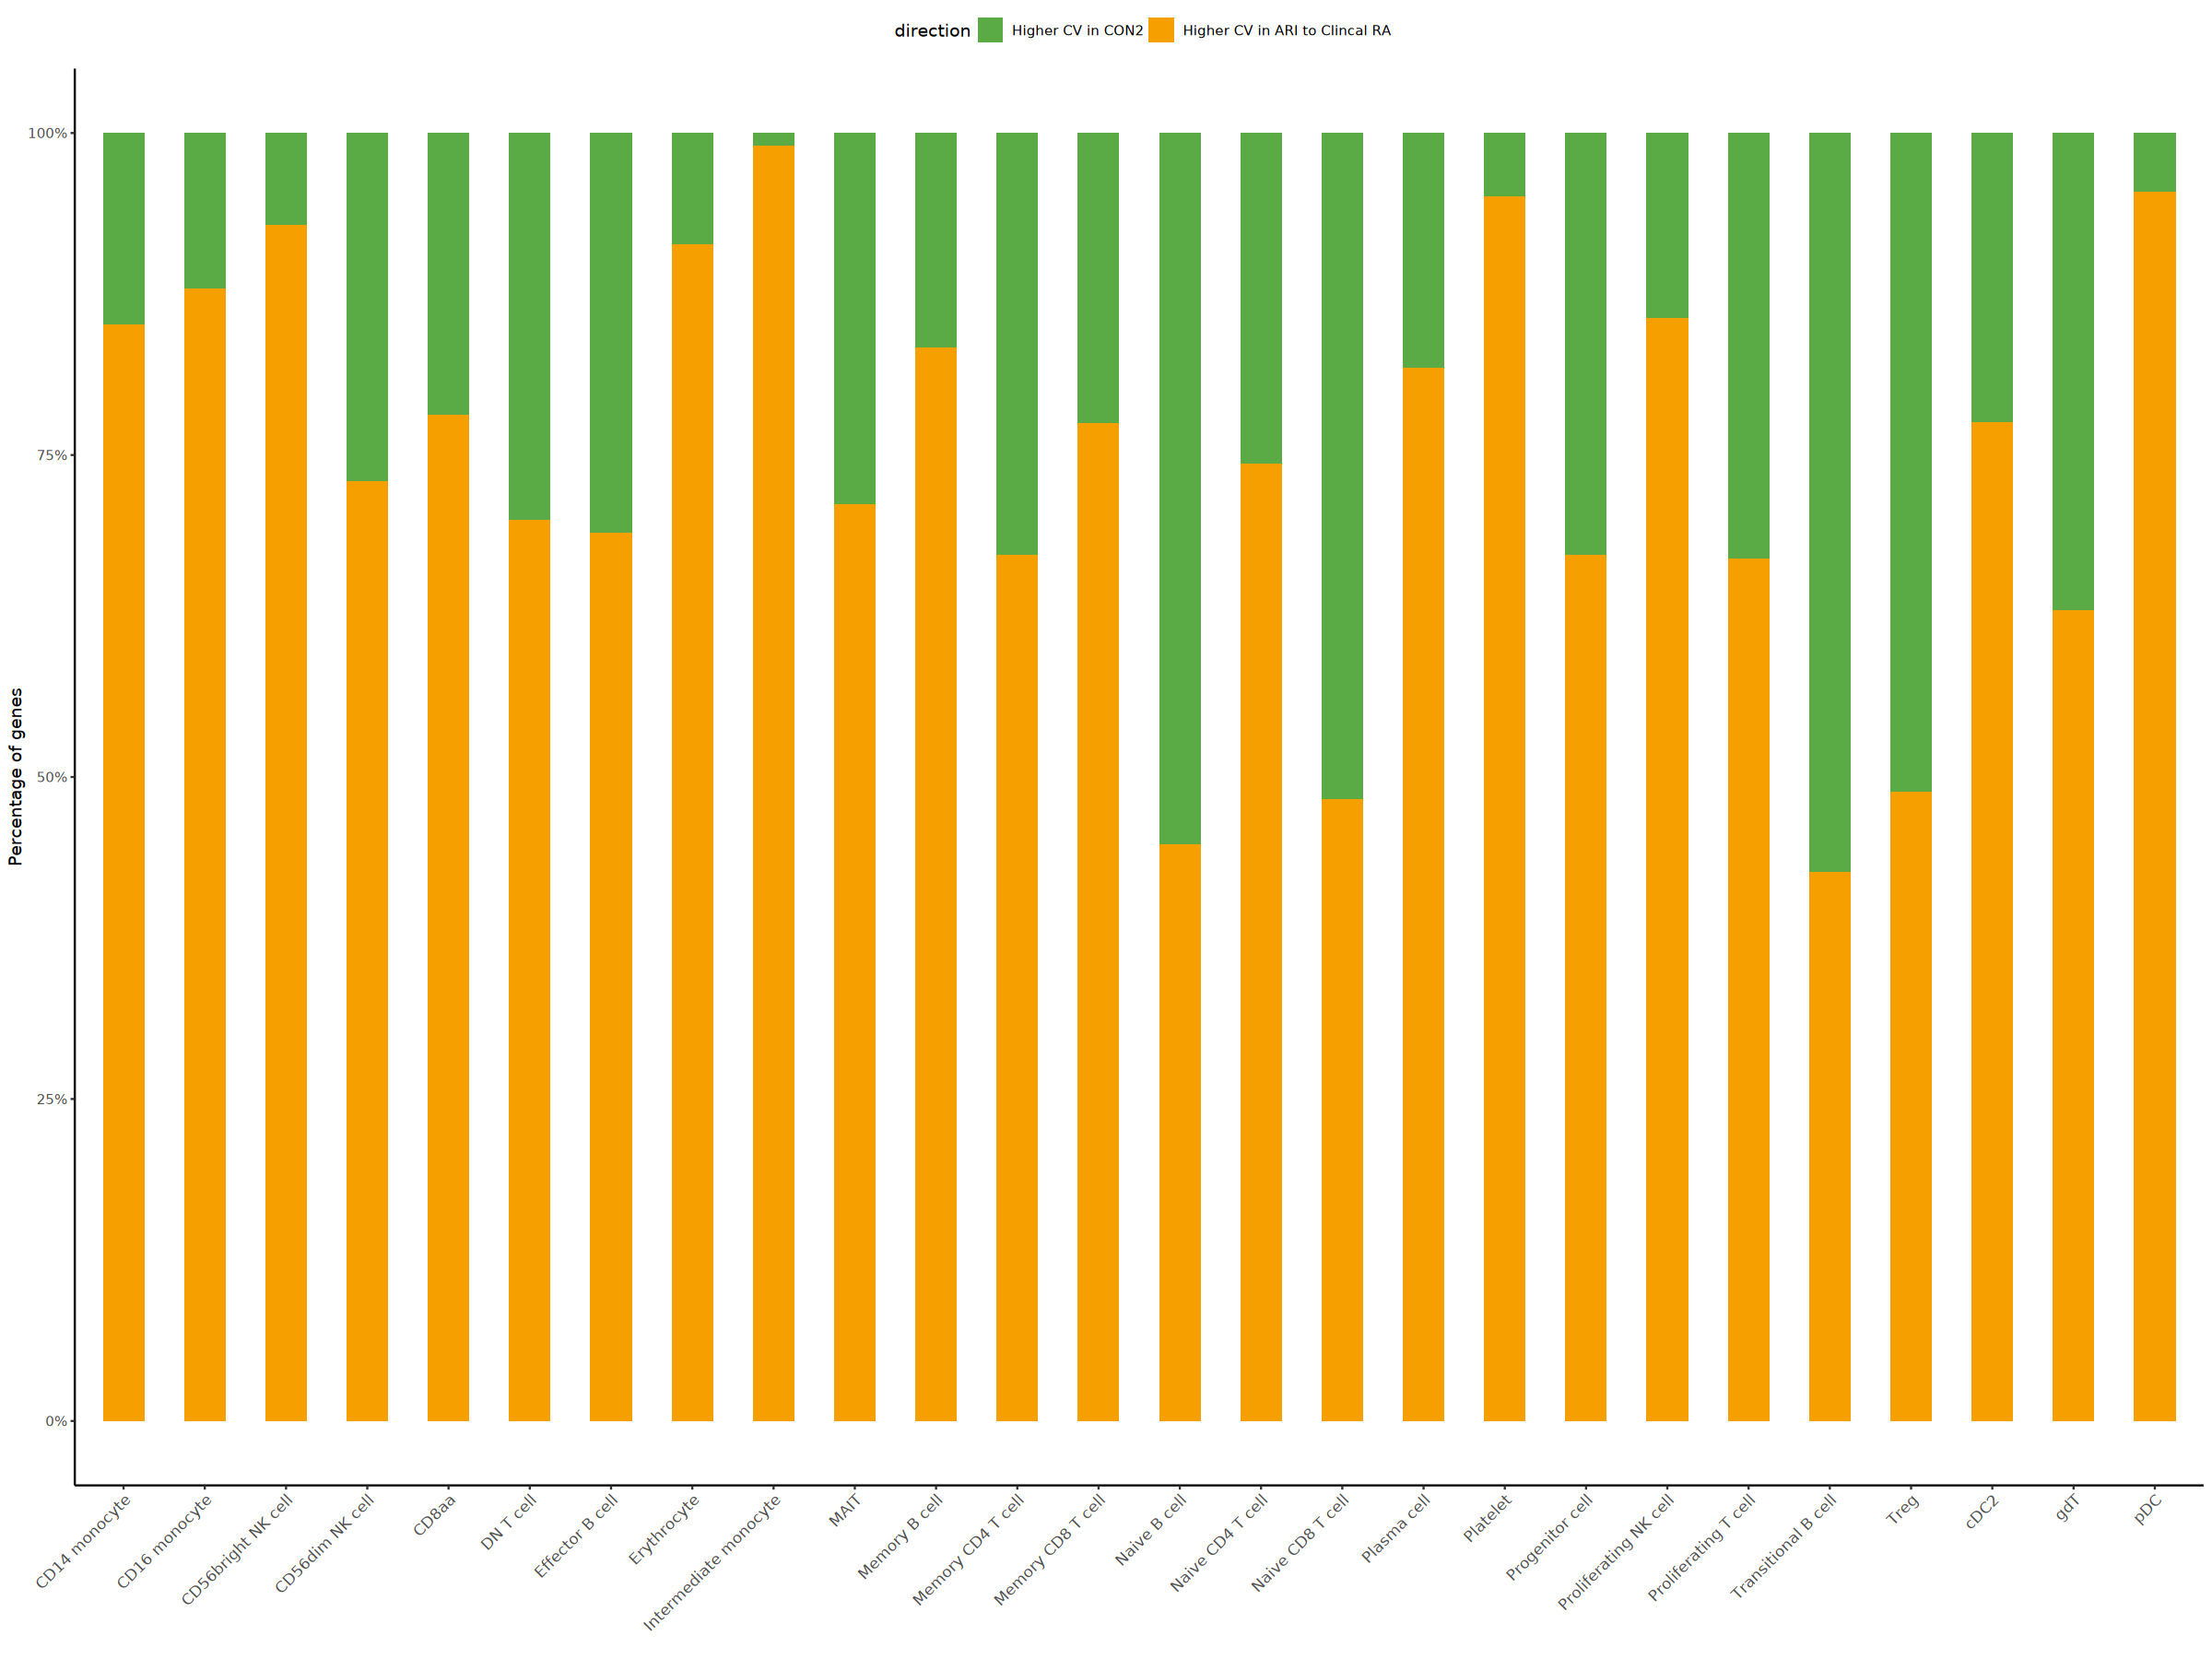

In [84]:
# plot the deg counts
p1 <- ggplot(cv_direction_counts, 
             aes(width = 0.5, fill = direction, y = pct, x = `Cell type`)) +
  geom_col() +
  ylab("Percentage of genes") +
  xlab("") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
    legend.position = "top",
    strip.text = element_text(size = 10)
  ) +
  scale_fill_manual(values = c(
    "#5AAA46",
    "#F59F00"
  )) +
  scale_y_continuous(labels = scales::percent)

p1
# ggsave(file.path(fig_path, paste0(proj_name, 'cv_barplot_percent.pdf')), width = 6, height = 4)

In [ ]:
# calcualte the CI for forest plot
celltype_cv_ci <- celltype_cv_ratio %>%
  group_by(cell_type) %>%
  rstatix::get_summary_stats(ratio_cv)
celltype_cv_ci %>% head()

In [ ]:
lm_test <- lm(ratio_cv ~ 1, celltype_cv_ratio %>% filter(cell_type == "CD14 monocyte"))
confint(lm_test, level = 0.95)

In [ ]:
# plot forest plot
p1 <- celltype_cv_ci %>%
  arrange(desc(mean)) %>%
  mutate(cell_type = factor(cell_type, levels = unique(cell_type))) %>%
  ggplot(aes(x = cell_type)) +
  geom_segment(aes(xend = cell_type, y = mean - ci, yend = mean + ci), ) +
  geom_point(aes(y = mean),
    size = 1,
    color = "orange"
  ) +
  geom_hline(yintercept = 1, color = "red", linetype = "dashed") +
  ggthemes::theme_clean() +
  xlab("") +
  ylab("ratio of mean CV") +
  theme(axis.text.x = element_text(
    angle = 90, vjust = 0.5, hjust = 1
  ))
p1
ggsave(file.path(fig_path, paste0(proj_name, "CV_mean_ratio_forest_plot.png")), width = 12, height = 6)

In [ ]:
mean_vc <- celltype_cv %>%
  group_by(cell_type, feature, status) %>%
  summarise(mean_cv = mean(CV)) %>%
  arrange(feature) %>%
  ungroup()
mean_vc %>% head()

In [ ]:
# celltype_cv

In [ ]:
mean_cv_test <- celltype_cv %>%
  group_by(cell_type, feature, status) %>%
  summarise(mean_cv = mean(CV)) %>%
  arrange(feature) %>%
  ungroup() %>%
  group_by(cell_type) %>%
  rstatix::t_test(data = ., mean_cv ~ status, paired = FALSE) %>%
  rstatix::adjust_pvalue(method = "BH") %>%
  rstatix::add_significance("p.adj")

In [ ]:
mean_cv_test %>%
  arrange(p) %>%
  head(10)

In [ ]:
celltype_cv_fl <- celltype_cv %>% filter(feature %in% celltype_cv_ratio$feature)

In [ ]:
celltype_cv_ratio %>% ggplot(aes(x = ratio_cv)) +
  geom_histogram() +
  facet_wrap(vars(cell_type)) +
  xlim(c(0, 2)) +
  geom_vline(xintercept = 1, color = "red", linetype = "dashed")
ggsave(file.path(fig_path, paste0(proj_name, "meanCVratio_distribution.png")), width = 12, height = 8)

In [ ]:
celltype_cv_ratio %>% head()

In [ ]:
# test cv in parallel
celltypes <- celltype_cv_fl %>%
  distinct(cell_type) %>%
  pull(cell_type)
cv_stats_wilcox_test <- mclapply(celltypes, function(x) {
  celltype_cv_ct <- celltype_cv_fl %>% filter(cell_type == x)
  cv_stats_wilcox_test <- celltype_cv_ct %>%
    # mutate(status=factor(status, levels = c('bri_healthy', 'converters'))) %>%
    group_by(feature) %>%
    rstatix::wilcox_test(data = ., CV ~ status, paired = FALSE) %>%
    rstatix::adjust_pvalue(method = "BH") %>%
    rstatix::add_significance("p.adj") %>%
    mutate(cell_type = x)
  return(cv_stats_wilcox_test)
}, mc.cores = 15) %>% rbindlist()

In [ ]:
cv_stats_wilcox_test %>%
  filter(p.adj < 0.05) %>%
  group_by(cell_type) %>%
  tally()

In [ ]:
cv_stats_wilcox_test %>% filter(p.adj < 0.05 & str_detect(feature, "CD\\d|IL\\d"))

In [ ]:
cv_stats_wilcox_test %>%
  arrange(p.adj) %>%
  head()

In [ ]:
# plot one gene in one cell type
celltype_cv_test <- celltype_cv %>% filter(feature == "IL17RA" & cell_type == "Intermediate monocyte")
celltype_cv_test %>% ggviolin(x = "status", y = "CV", add = "dotplot", color = "status")

In [ ]:
cv_stats_wilcox_test %>% write_tsv(file.path(output_path, paste0(proj_name, "CV_celltype_wilcox_test.tsv")))

In [ ]:
cv_stats_wilcox_test <- read_tsv(file.path(output_path, paste0(proj_name, "CV_celltype_wilcox_test.tsv")))

In [ ]:
# calculate effect size
celltypes <- celltype_cv_fl %>%
  distinct(cell_type) %>%
  pull(cell_type)
cv_stats_effect_size <- mclapply(celltypes, function(x) {
  celltype_cv_ct <- celltype_cv_fl %>% filter(cell_type == x)
  cv_stats_cohen <- celltype_cv_ct %>%
    mutate(status = factor(status, levels = c("bri_healthy", "converters"))) %>%
    group_by(feature) %>%
    rstatix::cohens_d(data = ., CV ~ status, ref.group = "bri_healthy") %>%
    mutate(cell_type = x)
  return(cv_stats_cohen)
}, mc.cores = 15) %>% rbindlist()

In [ ]:
celltypes

In [ ]:
cv_stats_effect_size %>%
  filter(cell_type == "Naive CD4 T cell") %>%
  arrange(effsize) %>%
  head(10)

In [ ]:
cv_stats_wilcox_sig <- cv_stats_wilcox_test %>%
  filter(p < 0.05) %>%
  left_join(select(cv_stats_effect_size, c(cell_type, effsize, feature)),
    by = c("cell_type", "feature")
  )

In [ ]:
cv_stats_effect_size %>% write_tsv(file.path(output_path, paste0(proj_name, "CV_celltype_effect_size_090324.tsv")))

In [63]:
cv_stats_effect_size <- read_tsv(
    '/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/ALTRA_AIM3_BRI_scRNA_PALMO_CV_celltype_effect_size.tsv')

Rows: 114177 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): .y., group1, group2, feature, magnitude, cell_type
dbl (3): effsize, n1, n2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [64]:
cv_stats_effect_size <- cv_stats_effect_size %>%
  mutate(direction = factor(if_else(effsize < 0, "Higher CV in ARI to Clincal RA",
    "Higher CV in CON2"
  ), levels = c("Higher CV in CON2", "Higher CV in ARI to Clincal RA")))

In [65]:
cv_stats_effect_size %>% head()

.y.,group1,group2,effsize,feature,n1,n2,magnitude,cell_type,direction
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
CV,bri_healthy,converters,-0.23826550,A1BG,29,15,small,CD14 monocyte,Higher CV in ARI to Clincal RA
CV,bri_healthy,converters,-0.18085730,A2M-AS1,29,15,negligible,CD14 monocyte,Higher CV in ARI to Clincal RA
CV,bri_healthy,converters,-0.38752243,ABCD1,29,15,small,CD14 monocyte,Higher CV in ARI to Clincal RA
CV,bri_healthy,converters,-0.08266245,ABCD4,29,15,negligible,CD14 monocyte,Higher CV in ARI to Clincal RA
CV,bri_healthy,converters,-0.21221527,ABCE1,29,15,small,CD14 monocyte,Higher CV in ARI to Clincal RA
CV,bri_healthy,converters,-0.39245114,ABHD12,29,15,small,CD14 monocyte,Higher CV in ARI to Clincal RA


### plot fig 2B

In [66]:
# calcualte the counts of genes with higher CV in ARI or CON2
cv_direction_counts <- cv_stats_effect_size %>%
  filter(cell_type != "cDC1") %>%
  group_by(cell_type, direction) %>%
  tally() %>%
  mutate(counts = if_else(direction == "Higher CV in converters", -n, n), pct = prop.table(n))
cv_direction_counts %>% head()

cell_type,direction,n,counts,pct
<chr>,<fct>,<int>,<int>,<dbl>
CD14 monocyte,Higher CV in CON2,1142,1142,0.14912510
CD14 monocyte,Higher CV in ARI to Clincal RA,6516,6516,0.85087490
CD16 monocyte,Higher CV in CON2,723,723,0.12104470
CD16 monocyte,Higher CV in ARI to Clincal RA,5250,5250,0.87895530
CD56bright NK cell,Higher CV in CON2,264,264,0.07179766
CD56bright NK cell,Higher CV in ARI to Clincal RA,3413,3413,0.92820234


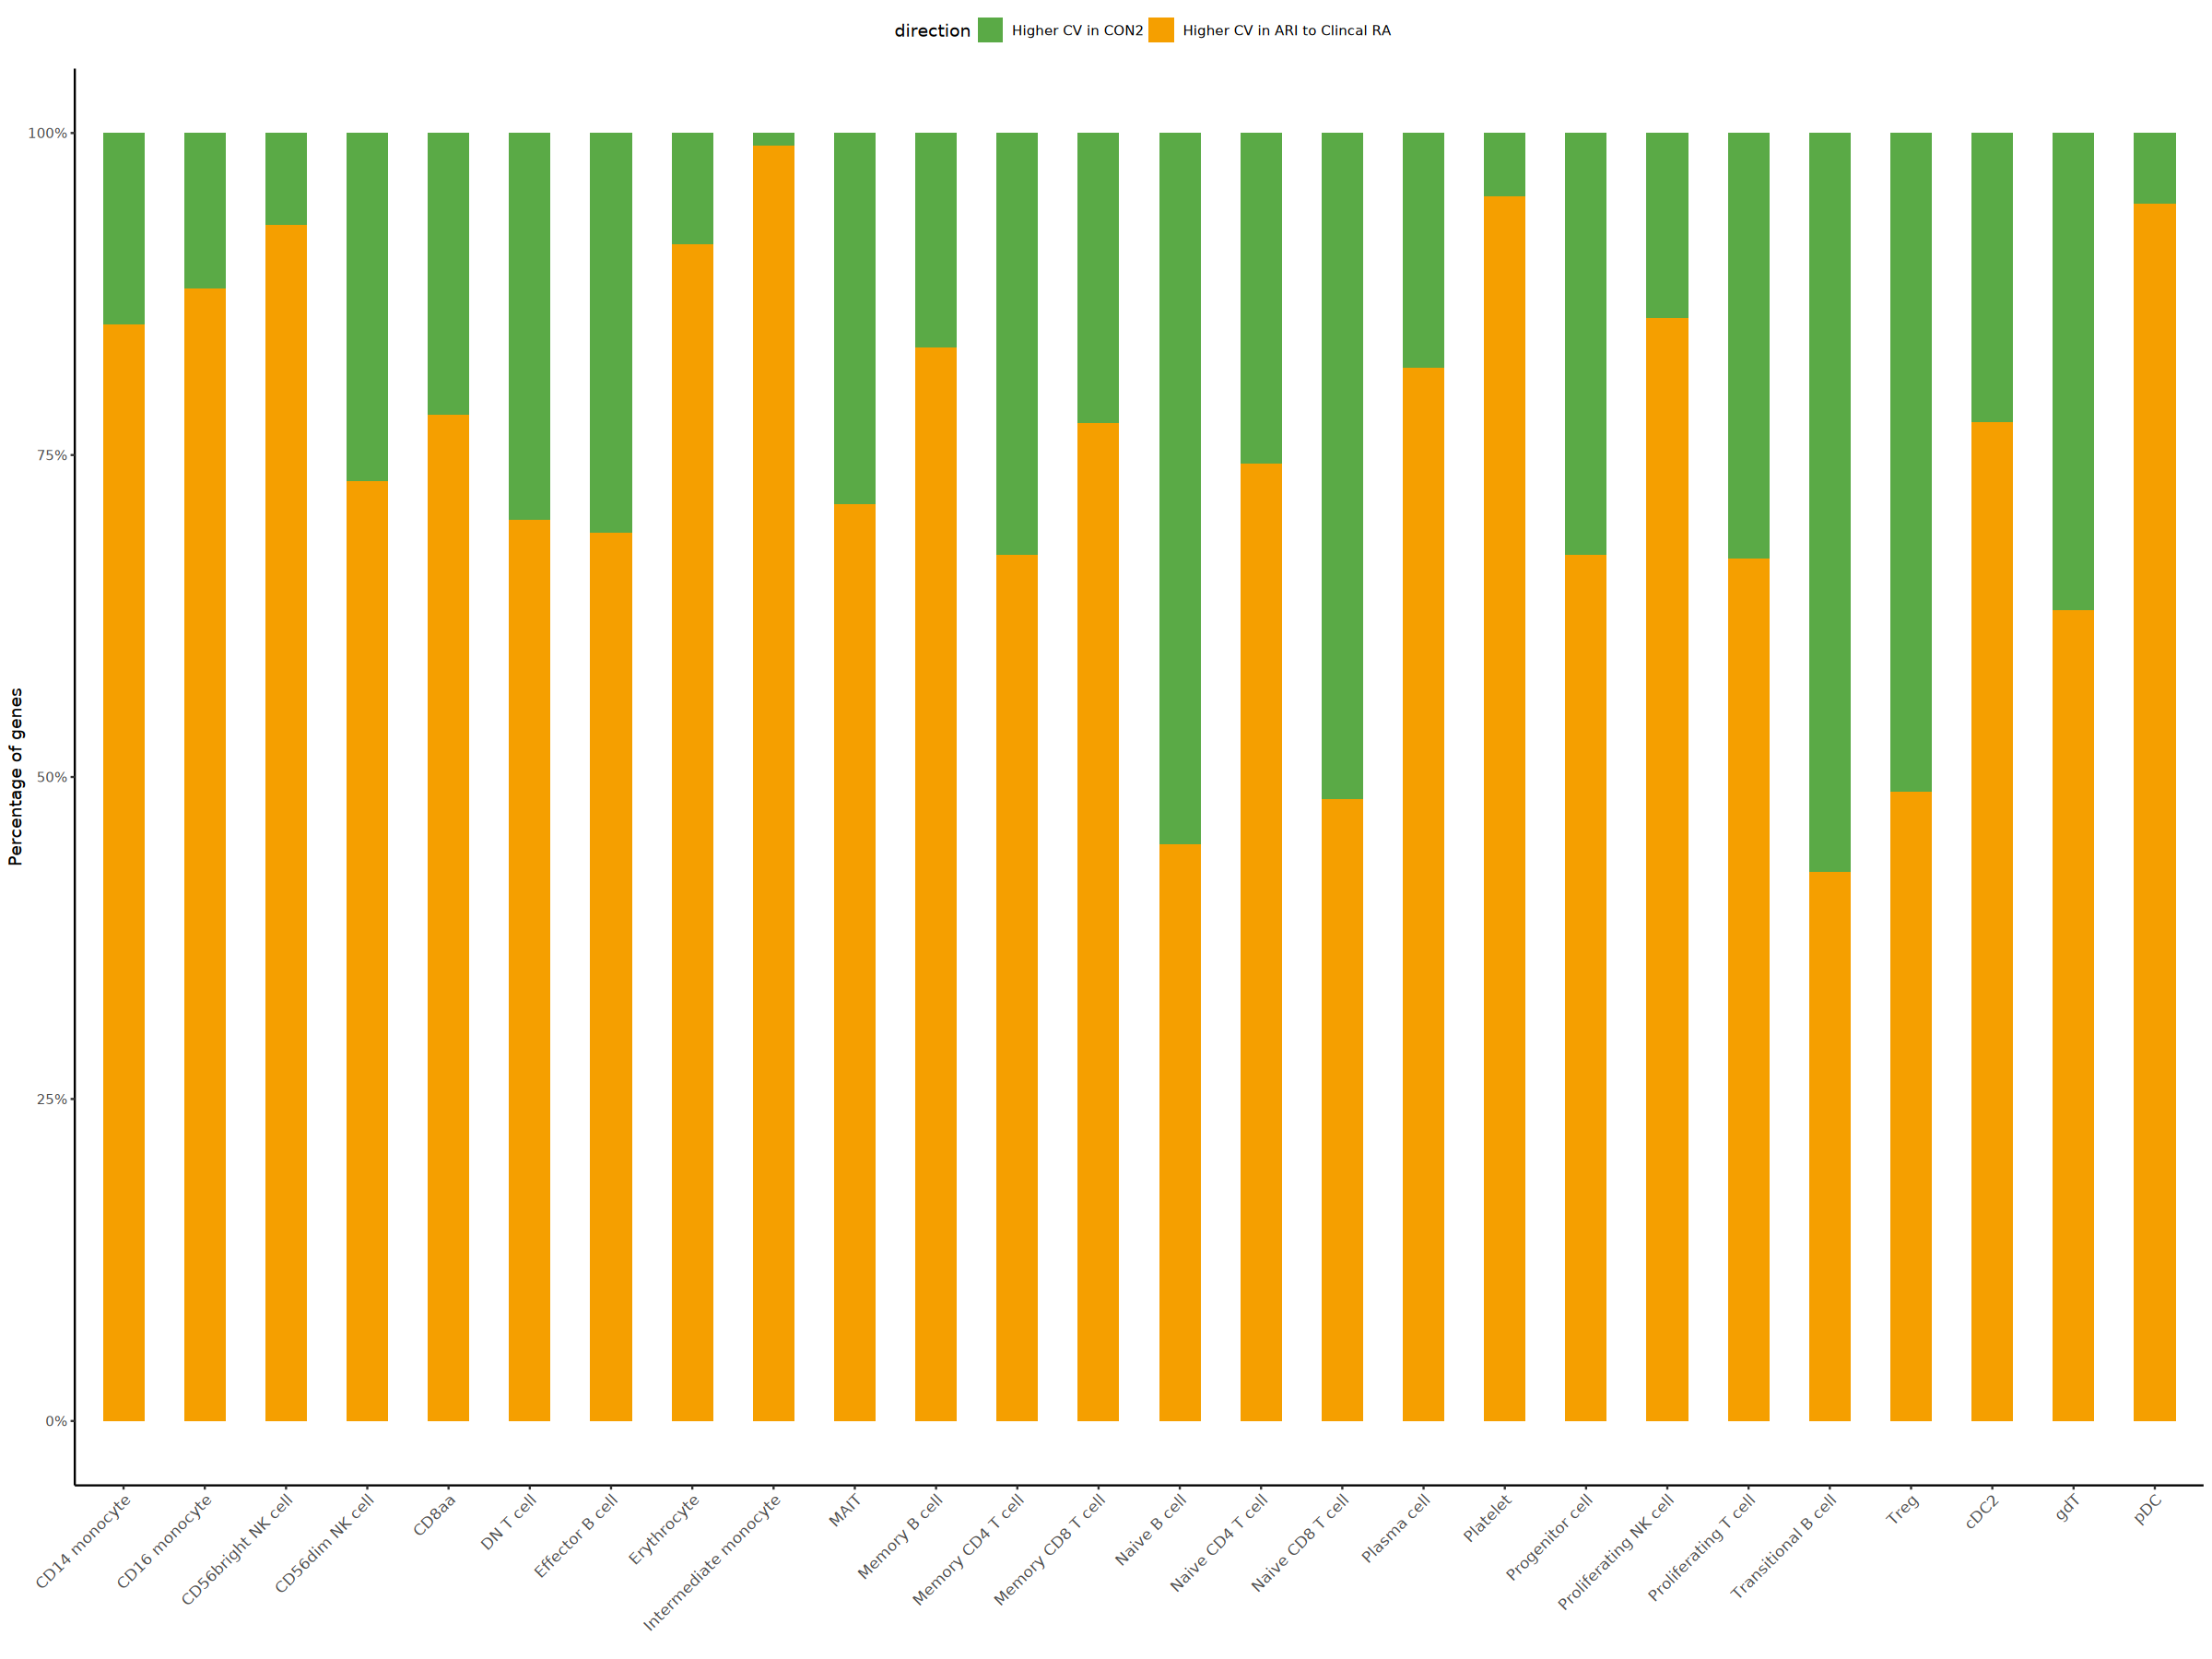

In [67]:
# plot the deg counts
p1 <- ggplot(cv_direction_counts, aes(width = 0.5, fill = direction, y = pct, x = cell_type)) +
  geom_col() +
  # geom_text(aes(label = scales::percent(pct, accuracy = .1)),
  #           position = position_stack(vjust = .5), size=2) +
  # scale_y_continuous(breaks = seq(-2000, 1200, by = 200)) +
  # geom_text(aes(y = n + 50 * sign(n), label = abs(n)), vjust = 0, size=4) +
  ylab("Percentage of genes") +
  xlab("") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
    legend.position = "top",
    strip.text = element_text(size = 10)
  ) +
  scale_fill_manual(values = c(
    "#5AAA46",
    "#F59F00"
  )) +
  scale_y_continuous(labels = scales::percent)
p1
# Adding line to differentiate -ve and +ve y axis
# p2 <- ggpubr::ggbarplot(cv_direction_counts, xlab = 'global cell types', ylab='Number of Genes',
#                         x='cell_type', y='n', color = "direction", fill='direction',
#                         position = position_dodge(0.8),
#                         palette = c("#0072B5FF", "#BC3C29FF"))+
#     theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 12),
#          strip.text = element_text(size=12))
# p2
# ggsave(file.path(fig_path, paste0(proj_name, "cv_barplot_percent.pdf")), width = 6, height = 4)

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


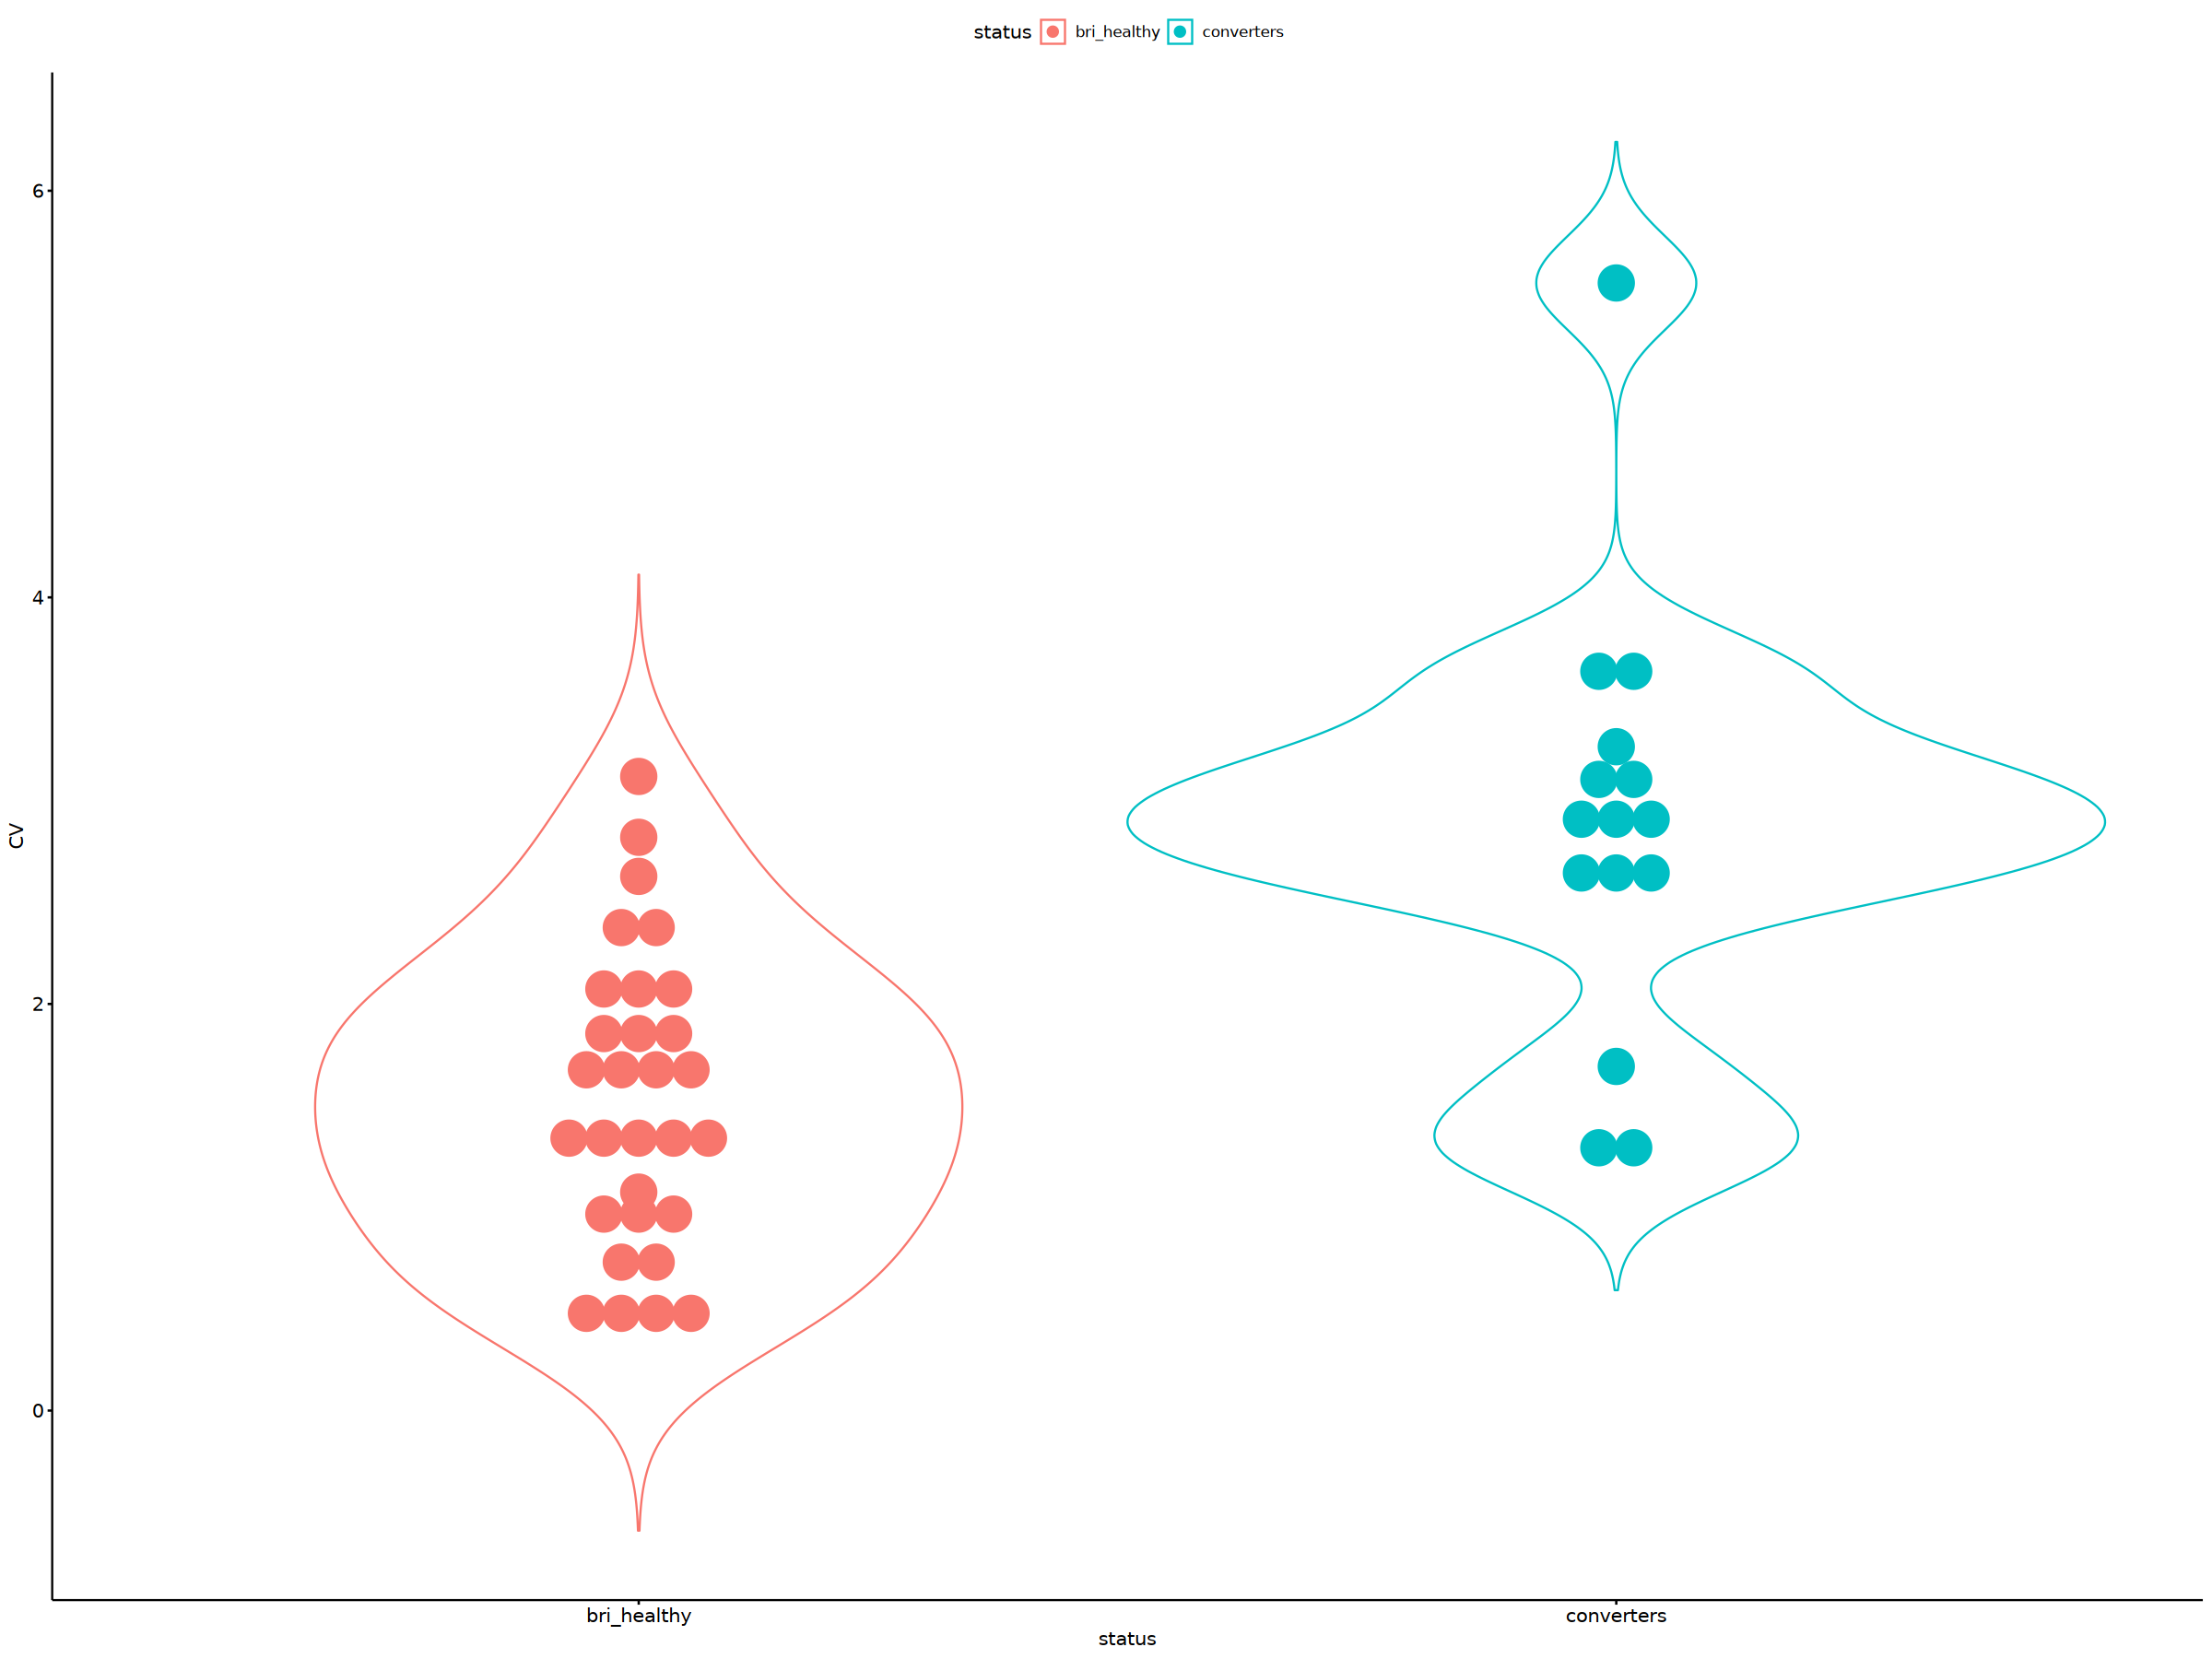

In [68]:
# plot one gene in one cell type
celltype_cv %>%
  mutate(status = factor(status, levels = c("bri_healthy", "converters"))) %>%
  filter(feature == "UCK1" & cell_type == "Naive CD4 T cell") %>%
  ggviolin(x = "status", y = "CV", add = "dotplot", color = "status")

In [ ]:
cv_stats_wilcox_test <- read_tsv(file.path(output_path, paste0(proj_name, "CV_celltype_wilcox_test.tsv")))

In [ ]:
celltype_cv_ratio %>%
  filter(cell_type == "Core_CD16_monocyte") %>%
  arrange(desc(ratio_cv))